# Section 1: Introduction

In this project, a spring-mass-damper system is used to model the vertical dynamics of a vehicle suspension. Specifically, a quarter-car suspension model is considered, representing one corner of a passenger vehicle. This model is commonly used in mechanical and aerospace engineering to analyze how vehicles respond to road disturbances such as bumps or uneven terrain.

For this study, the system is modeled after a typical mid-size passenger sedan, such as a Toyota Camry. In a quarter-car approximation, the total vehicle mass is divided among four suspension systems, allowing each wheel assembly to be analyzed independently. This simplification captures the essential dynamics of vertical motion while remaining computationally efficient.

The governing equation for the system is given by:

m (d^2y / dt^2) + c (dy/dt) + ky = 0 

where y(t) is the displacement from equilibrium, m is mass, c is damping coefficient, and k is spring stiffness.

To apply numerical methods, the equation is converted into a first-order system:

y1=y,

y2=dy/dt,

giving:

d(y1)/dt = y2,

d(y2)/dt = (-c/m)y2 - (k/m)y1

This system describes the evolution of displacement and velocity over time.

# Section 2: Parameters

The selected system is a simplified quarter-car suspension model. A quarter-car model represents the vertical motion of one corner of a vehicle, where the sprung mass is supported by a suspension spring and damper. This is a useful approximation for studying how a vehicle body responds after hitting a road disturbance.

The parameters were selected from typical passenger sedan suspension values. The sprung mass was chosen as m=250 kg, the damping coefficient as c=1000 N·s/m, and the spring stiffness as k=16000 N/m. These values are realistic for a passive passenger vehicle suspension model (https://www.jchps.com/specialissues/Special%20issue%207/10%20MITNC%20Prabhakar%2032-36.pdf).

The initial displacement was set to y(0)=0.10 m to represent the vehicle body being displaced upward after encountering a bump. The initial velocity was set to y′(0)=0 m/s, assuming the car body begins the simulation at maximum displacement with no initial vertical velocity.

Using these parameters, the natural frequency is:

ωn= sqrt(k/m) =8 rad/s 

and the damping ratio is:

ζ= (c/2sqrt(mk)) = 0.25

Since ζ<1, the system is underdamped, so the displacement should oscillate while decreasing in amplitude over time.


# Section 3: Numerical Methods Implementation

In [4]:
# ============================================================
# Numerical Methods Implementation (CODE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COE 311K Final Project - Spring-Mass-Damper System
# Numerical Solution of Second-Order ODEs
# ============================================================

# -----------------------------
# Parameters
# -----------------------------
m = 250       # mass, kg
c = 1000      # damping coefficient, N*s/m
k = 16000     # spring constant, N/m

# Initial conditions
y0 = 0.10     # initial displacement, m
v0 = 0.0      # initial velocity, m/s
Y0 = np.array([y0, v0])

# Time interval
t0 = 0
tf = 5

# Useful system values
omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(m * k))
omega_d = omega_n * np.sqrt(1 - zeta**2)

print("Natural frequency omega_n:", omega_n, "rad/s")
print("Damping ratio zeta:", zeta)
print("Damped frequency omega_d:", omega_d, "rad/s")


# -----------------------------
# First-order system
# -----------------------------
def spring_mass_system(t, Y):
    """
    First-order form of the spring-mass-damper equation.

    Original equation:
        m*y'' + c*y' + k*y = 0

    Let:
        Y[0] = y = displacement
        Y[1] = v = y' = velocity

    Then:
        y' = v
        v' = -(c/m)*v - (k/m)*y
    """
    y = Y[0]
    v = Y[1]

    dydt = v
    dvdt = -(c / m) * v - (k / m) * y

    return np.array([dydt, dvdt])


# -----------------------------
# Euler Forward Method
# -----------------------------
def euler_forward(f, Y0, t0, tf, h):
    """
    Euler Forward method for a system of first-order ODEs.
    """
    t_values = np.arange(t0, tf + h, h)
    Y_values = np.zeros((len(t_values), len(Y0)))

    Y_values[0] = Y0

    for i in range(len(t_values) - 1):
        Y_values[i + 1] = Y_values[i] + h * f(t_values[i], Y_values[i])

    return t_values, Y_values


# -----------------------------
# RK4 Method
# -----------------------------
def rk4(f, Y0, t0, tf, h):
    """
    Fourth-order Runge-Kutta method for a system of first-order ODEs.
    """
    t_values = np.arange(t0, tf + h, h)
    Y_values = np.zeros((len(t_values), len(Y0)))

    Y_values[0] = Y0

    for i in range(len(t_values) - 1):
        t = t_values[i]
        Y = Y_values[i]

        k1 = f(t, Y)
        k2 = f(t + h / 2, Y + (h / 2) * k1)
        k3 = f(t + h / 2, Y + (h / 2) * k2)
        k4 = f(t + h, Y + h * k3)

        Y_values[i + 1] = Y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return t_values, Y_values


# -----------------------------
# Analytical Solution
# -----------------------------
def analytical_solution(t):
    """
    Analytical solution for an underdamped spring-mass-damper system.

    y(t) = e^(-zeta*omega_n*t) [A cos(omega_d*t) + B sin(omega_d*t)]
    """
    A = y0
    B = (v0 + zeta * omega_n * y0) / omega_d

    y = np.exp(-zeta * omega_n * t) * (
        A * np.cos(omega_d * t) + B * np.sin(omega_d * t)
    )

    return y




Natural frequency omega_n: 8.0 rad/s
Damping ratio zeta: 0.25
Damped frequency omega_d: 7.745966692414834 rad/s


# Section 4: Solutions & Comparison

### Euler Method: Displacement vs. Time

Euler Method: Implementation Explanation

The Euler Forward method is used to numerically approximate the displacement of the spring-mass-damper system. Simulations are performed using multiple step sizes (h = 0.1, 0.05, 0.01) to examine how step size affects solution accuracy. The results are compared to the analytical solution to evaluate the performance of the method.

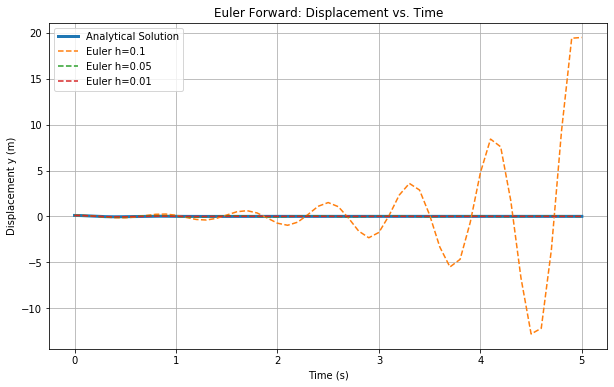

In [6]:
# ============================================================
# Solution Comparison for Multiple Step Sizes
# ============================================================

step_sizes = [0.1, 0.05, 0.01]

plt.figure(figsize=(10, 6))

t_exact = np.linspace(t0, tf, 1000)
y_exact = analytical_solution(t_exact)

plt.plot(t_exact, y_exact, label="Analytical Solution", linewidth=3)

for h in step_sizes:
    t_euler, Y_euler = euler_forward(spring_mass_system, Y0, t0, tf, h)
    plt.plot(t_euler, Y_euler[:, 0], "--", label=f"Euler h={h}")

plt.title("Euler Forward: Displacement vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y (m)")
plt.legend()
plt.grid(True)
plt.show()

Euler Method: Interpretation

The Euler method captures the general oscillatory behavior expected for an underdamped system. 
However, significant differences from the analytical solution are observed, particularly for larger step sizes. 
For h = 0.1, the numerical solution exhibits noticeable amplitude and phase errors, indicating poor accuracy. 
As the step size decreases, the solution improves and more closely follows the analytical curve. This behavior demonstrates 
that Euler’s method is highly sensitive to step size and accumulates numerical error over time. Overall, while Euler’s
method can approximate the system behavior, it requires very small step sizes to achieve acceptable accuracy.

### RK4 Method: Displacement vs. Time

RK4 Method: Implementation Explanation

The Fourth-Order Runge-Kutta (RK4) method is applied to solve the same system using identical step sizes
(h = 0.1, 0.05, 0.01). RK4 improves upon Euler’s method by evaluating multiple intermediate slopes within each time step, 
leading to higher-order accuracy. The numerical results are again compared to the analytical solution.

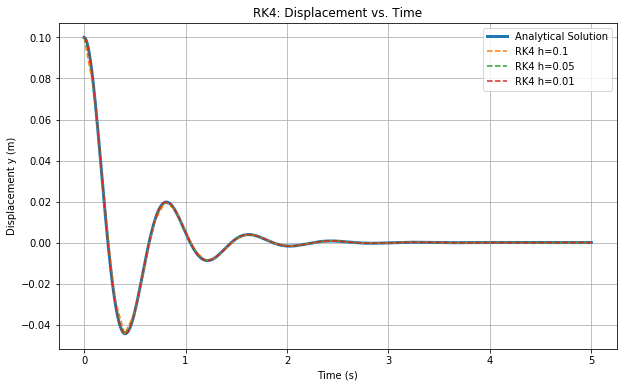

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(t_exact, y_exact, label="Analytical Solution", linewidth=3)

for h in step_sizes:
    t_rk4, Y_rk4 = rk4(spring_mass_system, Y0, t0, tf, h)
    plt.plot(t_rk4, Y_rk4[:, 0], "--", label=f"RK4 h={h}")

plt.title("RK4: Displacement vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y (m)")
plt.legend()
plt.grid(True)
plt.show()

Rk4 Method: Interpretation

The RK4 method produces solutions that closely match the analytical solution across all tested step sizes. Even for relatively large step sizes such as h = 0.1, the numerical solution remains accurate, with minimal amplitude and phase error.

Compared to Euler’s method, RK4 exhibits significantly improved stability and accuracy. The curves for smaller step sizes are nearly indistinguishable from the analytical solution, demonstrating the effectiveness of higher-order methods in reducing numerical error.

These results highlight that RK4 provides a much more reliable approximation for oscillatory systems, especially when computational efficiency is important.

### Direct Comparison of Numerical Methods

Direct Comparison: Implementation Explanation

To directly evaluate the performance of the numerical methods, the Euler and RK4 solutions are plotted alongside the analytical solution using a fixed step size (h = 0.01). This allows for a clear comparison of accuracy, phase behavior, and overall agreement with the true solution.

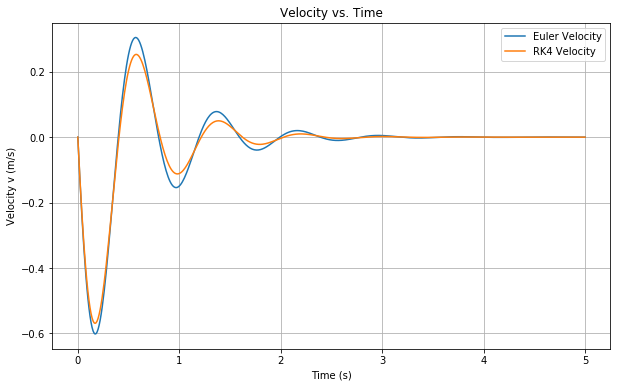

In [7]:
# ============================================================
# Velocity Comparison
# ============================================================

h = 0.01

t_euler, Y_euler = euler_forward(spring_mass_system, Y0, t0, tf, h)
t_rk4, Y_rk4 = rk4(spring_mass_system, Y0, t0, tf, h)

plt.figure(figsize=(10, 6))
plt.plot(t_euler, Y_euler[:, 1], label="Euler Velocity")
plt.plot(t_rk4, Y_rk4[:, 1], label="RK4 Velocity")
plt.title("Velocity vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity v (m/s)")
plt.legend()
plt.grid(True)
plt.show()

Direct Comparison: Interpretation

The comparison plot clearly shows that RK4 provides a significantly more accurate approximation than Euler’s method. The RK4 solution closely overlaps with the analytical solution, indicating minimal numerical error.

In contrast, the Euler solution exhibits visible deviation, particularly in phase alignment and amplitude. This phase lag and distortion are the result of accumulated truncation error inherent in first-order methods.

These results demonstrate that RK4 is far more effective for capturing the dynamics of oscillatory systems, while Euler’s method becomes unreliable unless very small step sizes are used.

### Phase Portrait (Velocity vs. Displacement)

Phase Portrait: Implementation Explanation

A phase portrait is used to visualize the relationship between displacement and velocity. This representation provides insight into the system’s energy behavior and stability by showing how the state of the system evolves over time in phase space.

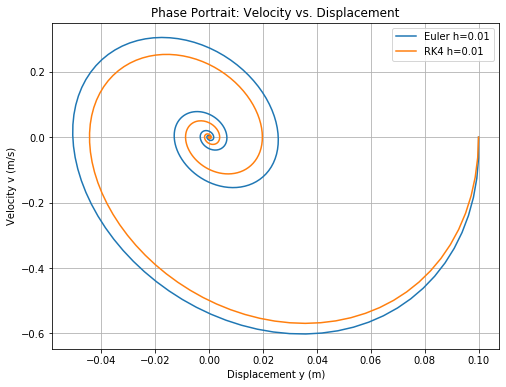

In [12]:

# ============================================================
# Phase Portrait
# ============================================================

plt.figure(figsize=(8, 6))
plt.plot(Y_euler[:, 0], Y_euler[:, 1], label="Euler h=0.01")
plt.plot(Y_rk4[:, 0], Y_rk4[:, 1], label="RK4 h=0.01")
plt.title("Phase Portrait: Velocity vs. Displacement")
plt.xlabel("Displacement y (m)")
plt.ylabel("Velocity v (m/s)")
plt.legend()
plt.grid(True)
plt.show()

Phase Portrait: Interpretation

The phase portrait exhibits an inward spiral, which is characteristic of an underdamped system. This indicates that the system is losing energy over time due to damping, causing the amplitude of oscillations to decrease as the system approaches equilibrium.

RK4 produces a smooth and well-defined spiral, closely representing the true physical behavior of the system. Euler’s method, while capturing the general trend, shows slight distortion in the trajectory, particularly as numerical error accumulates.

The inward spiral toward the origin confirms that both displacement and velocity decay to zero over time, consistent with the expected physical behavior of a damped mechanical system.

### Section 4: Summary of Results

Both numerical methods successfully reproduce the oscillatory behavior of the spring-mass-damper system. However, their accuracy differs significantly.

Euler’s method is highly sensitive to step size and accumulates numerical error quickly, leading to noticeable deviations from the analytical solution. In contrast, RK4 maintains strong agreement with the analytical solution across all tested step sizes.

These results demonstrate the importance of using higher-order numerical methods for accurately simulating dynamic systems, particularly when oscillatory behavior is involved.

# Section 5: Stability Analysis

### Step Size Investigation

To evaluate numerical stability, both Euler and RK4 methods are tested using increasingly large step sizes. Large step sizes can introduce instability in numerical methods, causing solutions to deviate significantly from expected physical behavior.

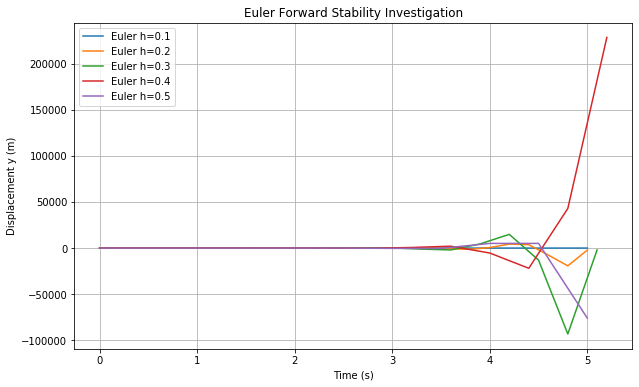

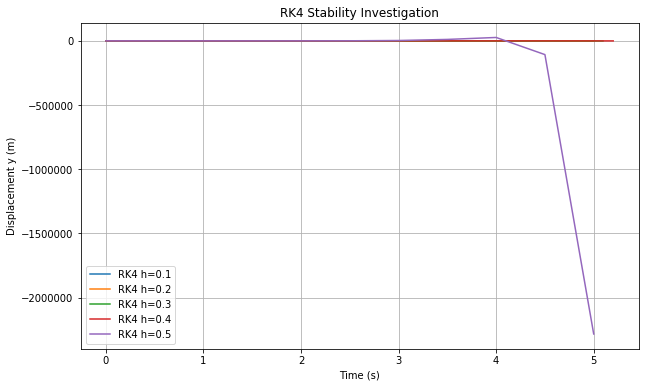

In [13]:

# ============================================================
# Stability Investigation
# ============================================================

large_step_sizes = [0.1, 0.2, 0.3, 0.4, 0.5]

plt.figure(figsize=(10, 6))

for h in large_step_sizes:
    t_euler, Y_euler = euler_forward(spring_mass_system, Y0, t0, tf, h)
    plt.plot(t_euler, Y_euler[:, 0], label=f"Euler h={h}")

plt.title("Euler Forward Stability Investigation")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y (m)")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))

for h in large_step_sizes:
    t_rk4, Y_rk4 = rk4(spring_mass_system, Y0, t0, tf, h)
    plt.plot(t_rk4, Y_rk4[:, 0], label=f"RK4 h={h}")

plt.title("RK4 Stability Investigation")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y (m)")
plt.legend()
plt.grid(True)
plt.show()

Step Size Investigation: Interpretation

As the step size increases, the Euler method quickly becomes unstable. For larger values of h, the solution exhibits growing oscillations instead of decaying behavior. This is non-physical, as the system being modeled is damped and should lose energy over time.

RK4 remains stable for a wider range of step sizes, although it also eventually shows instability when the step size becomes sufficiently large. This demonstrates that while higher-order methods improve stability, they are not unconditionally stable.

These results highlight the importance of selecting an appropriate step size to ensure physically meaningful solutions.

### Error Analysis

To quantify numerical accuracy, the maximum absolute error between the numerical solutions and the analytical solution is computed for various step sizes. A log-log plot of error versus step size is used to examine convergence behavior.

Step sizes: [0.2, 0.1, 0.05, 0.025, 0.0125]
Euler errors: [19255.484336793186, 19.50170260602365, 0.054797767759321346, 0.018905240427239983, 0.008010316807466444]
RK4 errors: [0.009871217707242313, 0.0005764282123762333, 3.479489406307823e-05, 2.111807812073263e-06, 1.2925967228516466e-07]


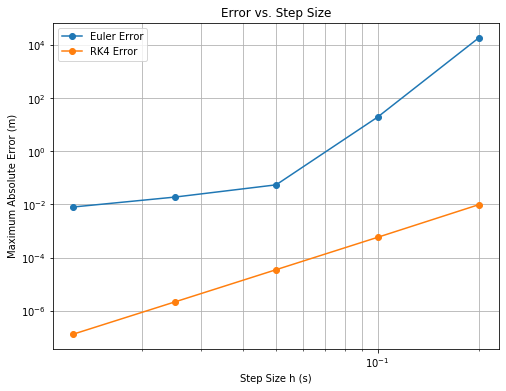

Estimated Euler convergence slope: 5.2404411720314386
Estimated RK4 convergence slope: 4.053385500346818


In [14]:

# ============================================================
# Error Analysis
# ============================================================

error_step_sizes = [0.2, 0.1, 0.05, 0.025, 0.0125]

euler_errors = []
rk4_errors = []

for h in error_step_sizes:
    # Euler
    t_euler, Y_euler = euler_forward(spring_mass_system, Y0, t0, tf, h)
    y_exact_euler = analytical_solution(t_euler)
    euler_error = np.max(np.abs(Y_euler[:, 0] - y_exact_euler))
    euler_errors.append(euler_error)

    # RK4
    t_rk4, Y_rk4 = rk4(spring_mass_system, Y0, t0, tf, h)
    y_exact_rk4 = analytical_solution(t_rk4)
    rk4_error = np.max(np.abs(Y_rk4[:, 0] - y_exact_rk4))
    rk4_errors.append(rk4_error)

print("Step sizes:", error_step_sizes)
print("Euler errors:", euler_errors)
print("RK4 errors:", rk4_errors)


plt.figure(figsize=(8, 6))
plt.loglog(error_step_sizes, euler_errors, "o-", label="Euler Error")
plt.loglog(error_step_sizes, rk4_errors, "o-", label="RK4 Error")
plt.title("Error vs. Step Size")
plt.xlabel("Step Size h (s)")
plt.ylabel("Maximum Absolute Error (m)")
plt.legend()
plt.grid(True, which="both")
plt.show()


# Estimate convergence slopes
euler_slope = np.polyfit(np.log(error_step_sizes), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(error_step_sizes), np.log(rk4_errors), 1)[0]

print("Estimated Euler convergence slope:", euler_slope)
print("Estimated RK4 convergence slope:", rk4_slope)

Error Analysis: Interpretation

The log-log plot shows that the error decreases as the step size decreases for both methods. Euler’s method exhibits approximately first-order convergence, meaning the error decreases linearly with step size.

In contrast, RK4 demonstrates significantly faster error reduction, consistent with fourth-order convergence. This is evident from the steeper slope of the RK4 curve compared to Euler.

These results confirm the theoretical expectations for both methods and demonstrate the advantage of higher-order numerical schemes in achieving greater accuracy.

The estimated slopes from the log-log plot further support the theoretical convergence rates. Euler’s method yields a slope close to 1, while RK4 produces a slope close to 4, confirming their respective orders of accuracy.

### Energy Analysis

The total mechanical energy of the system is analyzed to assess the physical realism of the numerical solutions. For a damped system, energy should decrease over time due to dissipation from the damping force.

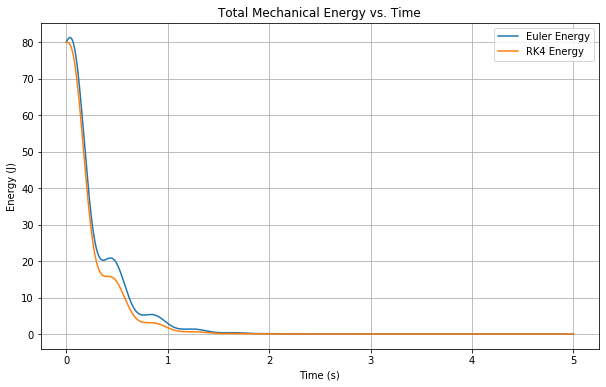

Final displacement using Euler h=0.01: 1.6934668493202793e-06 m
Final displacement using RK4 h=0.01: 3.339903720093667e-06 m
Final analytical displacement: 3.3398439215083893e-06 m


In [11]:
# ============================================================
# Energy Analysis
# ============================================================

def total_energy(Y):
    """
    Total mechanical energy:
        E = 1/2 m v^2 + 1/2 k y^2
    """
    y = Y[:, 0]
    v = Y[:, 1]

    E = 0.5 * m * v**2 + 0.5 * k * y**2

    return E


h = 0.01

t_euler, Y_euler = euler_forward(spring_mass_system, Y0, t0, tf, h)
t_rk4, Y_rk4 = rk4(spring_mass_system, Y0, t0, tf, h)

E_euler = total_energy(Y_euler)
E_rk4 = total_energy(Y_rk4)

plt.figure(figsize=(10, 6))
plt.plot(t_euler, E_euler, label="Euler Energy")
plt.plot(t_rk4, E_rk4, label="RK4 Energy")
plt.title("Total Mechanical Energy vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Final Summary Output
# ============================================================

print("Final displacement using Euler h=0.01:", Y_euler[-1, 0], "m")
print("Final displacement using RK4 h=0.01:", Y_rk4[-1, 0], "m")
print("Final analytical displacement:", analytical_solution(np.array([tf]))[0], "m")

Energy Analysis: Intepretation

The energy plots show that the total mechanical energy decreases over time, as expected for a damped system. This confirms that the numerical solutions capture the dissipative nature of the system.

RK4 produces a smooth and physically consistent energy decay, while Euler’s method may show slight deviations, particularly at larger step sizes. In unstable cases, the energy may increase artificially, indicating non-physical behavior caused by numerical error.

This analysis reinforces the importance of both stability and accuracy in numerical simulations.

### Physical Interpretation

The stability and accuracy of numerical methods directly impact the physical validity of the simulation. In this system, the presence of damping ensures that displacement, velocity, and energy should all decrease over time.

When numerical methods become unstable, they produce solutions that violate these physical constraints, such as increasing amplitude or energy. These behaviors are not representative of the real system and indicate that the chosen step size or method is inappropriate.

Overall, RK4 provides more reliable and physically consistent results across a wider range of step sizes, while Euler’s method requires careful selection of step size to avoid instability.

# Section 6: Conclusions

In this project, Euler’s Forward Method and the RK4 method were used to numerically solve a second-order differential equation representing a spring-mass-damper system.

The results showed that RK4 significantly outperforms Euler’s method in both accuracy and stability. While Euler’s method is simple to implement, it accumulates numerical error rapidly and becomes unstable for larger step sizes. RK4, on the other hand, maintains strong agreement with the analytical solution and remains stable over a wider range of step sizes.

The stability analysis demonstrated that inappropriate step sizes can lead to non-physical results, such as increasing energy in a damped system. This highlights the importance of carefully selecting numerical methods and parameters in engineering simulations.

Overall, RK4 is the preferred method for solving oscillatory systems due to its higher-order accuracy and improved stability characteristics.